About Project

An end-to-end data analysis project exploring the Saudi Arabian used car market. This project utilizes Python to clean, visualize, and extract key insights regarding vehicle pricing trends, regional demand, and mechanical specifications.

In [266]:
import pandas as pd
import matplotlib.pyplot as plt    
import plotly.express as px
import numpy as np
import seaborn as sns   

df_origin = pd.read_csv('UsedCarsSA_Unclean_EN.csv')
df = df_origin.copy()

In [267]:
df.sample(5)

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Condition,Mileage,Region,Price,Negotiable
7112,Cadillac,CT-S,2019,Saudi,White,Semi Full,2.0,Gas,Automatic,Used,43000,Dammam,135000,False
6709,Toyota,Land Cruiser,2013,Gulf Arabic,White,Full,NaN,Gas,Automatic,Used,250,Hail,Negotiable,True
482,Cadillac,XT5,2017,Gulf Arabic,White,Full,NaN,Gas,Automatic,Used,91000,Riyadh,130000,False
3315,Ford,Taurus,2018,Other,Black,Full,3.5,Gas,Automatic,Used,92000,Dammam,93000,False
4106,Chevrolet,Tahoe,2013,Saudi,Brown,Standard,NaN,Gas,Automatic,Used,315000,Dammam,Negotiable,True


In [268]:
df.shape

(8248, 14)

In [269]:
df.describe()

,Year,Engine_Size,Mileage
count,8248.000000,5982.000000,8.248000e+03
mean,2014.014064,3.175794,1.494128e+05
std,5.935349,1.567480,3.455258e+05
min,1936.000000,1.000000,1.000000e+02
25%,2012.000000,2.000000,3.700000e+04
50%,2016.000000,2.700000,1.016575e+05
75%,2018.000000,4.000000,1.955520e+05
max,2022.000000,9.000000,2.000000e+07


In [270]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8248 entries, 0 to 8247
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         8248 non-null   object 
 1   Type         8248 non-null   object 
 2   Year         8248 non-null   int64  
 3   Origin       8153 non-null   object 
 4   Color        8248 non-null   object 
 5   Options      8139 non-null   object 
 6   Engine_Size  5982 non-null   float64
 7   Fuel_Type    8248 non-null   object 
 8   Gear_Type    8174 non-null   object 
 9   Condition    8248 non-null   object 
 10  Mileage      8248 non-null   int64  
 11  Region       8248 non-null   object 
 12  Price        8248 non-null   object 
 13  Negotiable   8248 non-null   bool   
dtypes: bool(1), float64(1), int64(2), object(10)
memory usage: 845.9+ KB


Cleaning

In [271]:
# Origin, Options, Engine_Size and Gear_Type columns have some missing values, we need to handle them 
# Price column has some non-numeric values, we need to clean it
# Condition column not important for our analysis, we can drop it

In [272]:
df = df.drop(columns=['Condition'])

In [273]:
df.duplicated().sum()   

np.int64(69)

In [274]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [275]:
df.isna().sum() 

Make              0
Type              0
Year              0
Origin           95
Color             0
Options         109
Engine_Size    2254
Fuel_Type         0
Gear_Type        74
Mileage           0
Region            0
Price             0
Negotiable        0
dtype: int64

In [276]:
print(9500/8248)
# so the missing values in Origin column is around 1.15%, we can drop the rows with missing values in this column
df = df.dropna(subset=['Origin'])

1.1517943743937924


In [277]:
print(10900/8248)
# so the missing values in Options column is around 1.32%, we can drop the rows with missing values in this column
df = df.dropna(subset=['Options'])

1.3215324927255092


In [278]:
print(7400/8248)
# so the missing values in Gear_Type column is around 0.74%, we can drop the rows with missing values in this column
df = df.dropna(subset=['Gear_Type'])

0.8971871968962173


In [279]:
df['Engine_Size'] = df['Engine_Size'].fillna(
    df.groupby(['Year', 'Type', 'Make'])['Engine_Size']
      .transform('mean')
)

In [280]:
df['Engine_Size'] = df['Engine_Size'].fillna(
    df.groupby(['Make', 'Type', 'Year'])['Engine_Size']
      .transform('mean')
)

In [281]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Price'].info()

<class 'pandas.core.series.Series'>
Index: 8051 entries, 0 to 8247
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
5546 non-null   float64
dtypes: float64(1)
memory usage: 125.8 KB


In [282]:
df['Price'] = df['Price'].fillna(
    df.groupby(['Year', 'Type', 'Make'])['Price']
     .transform('mean'))

In [283]:
df.isna().sum()

Make             0
Type             0
Year             0
Origin           0
Color            0
Options          0
Engine_Size    430
Fuel_Type        0
Gear_Type        0
Mileage          0
Region           0
Price          503
Negotiable       0
dtype: int64

In [284]:
df['Engine_Size'] = df['Engine_Size'].fillna(df['Engine_Size'].mean())

In [285]:
df['Price'] = df['Price'].fillna(df['Price'].mean())

In [286]:
df.isna().sum() 

Make           0
Type           0
Year           0
Origin         0
Color          0
Options        0
Engine_Size    0
Fuel_Type      0
Gear_Type      0
Mileage        0
Region         0
Price          0
Negotiable     0
dtype: int64

In [287]:
df['Car_Age'] = 2024 - df['Year']
df['Car_Age']

0        6
1        8
2        5
3        5
4        5
        ..
8243     9
8244    14
8245    11
8246    13
8247    11
Name: Car_Age, Length: 8051, dtype: int64

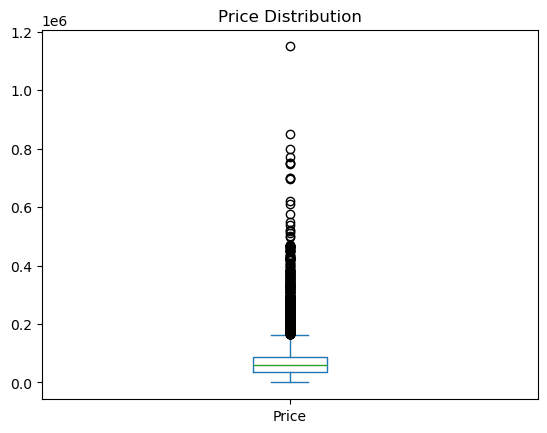

In [288]:
df['Price'].plot(kind='box', title='Price Distribution')
plt.show()

In [289]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print(f'Number of outliers in Price: {len(outliers)}')

Number of outliers in Price: 633


In [290]:
df[df['Price'] > upper_bound].sample(10)

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable,Car_Age
3790,Lexus,LS,2016,Other,Silver,Full,4.700000,Gas,Automatic,19000,Dammam,235000.000000,False,8
4653,Bentley,Flying Spur,2009,Saudi,White,Full,6.000000,Gas,Automatic,49000,Makkah,220000.000000,False,15
2530,Toyota,Land Cruiser,2018,Saudi,White,Standard,1.000000,Gas,Automatic,165000,Riyadh,228388.888889,True,6
7786,Mercedes,GLC,2020,Gulf Arabic,White,Semi Full,2.000000,Gas,Automatic,7000,Riyadh,275000.000000,False,4
426,Land Rover,Range Rover,2018,Saudi,White,Full,4.400000,Gas,Automatic,26000,Riyadh,170000.000000,False,6
6741,Mercedes,GLE,2020,Saudi,Navy,Full,3.000000,Gas,Automatic,13000,Dammam,375000.000000,False,4
13,Mercedes,CLA,2020,Other,White,Standard,3.277739,Gas,Automatic,20000,Riyadh,235000.000000,False,4
2522,Land Rover,Range Rover,2020,Saudi,White,Full,2.000000,Gas,Automatic,4200,Qassim,290000.000000,False,4
7993,Mercedes,S,2015,Other,White,Full,3.275000,Hybrid,Automatic,41305,Riyadh,221200.000000,True,9
4969,Ford,F150,2017,Saudi,White,Full,2.800000,Gas,Automatic,28000,Al-Medina,175000.000000,False,7


c:\Users\watan\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log



<Axes: title={'center': 'Log-Transformed Price Distribution'}>

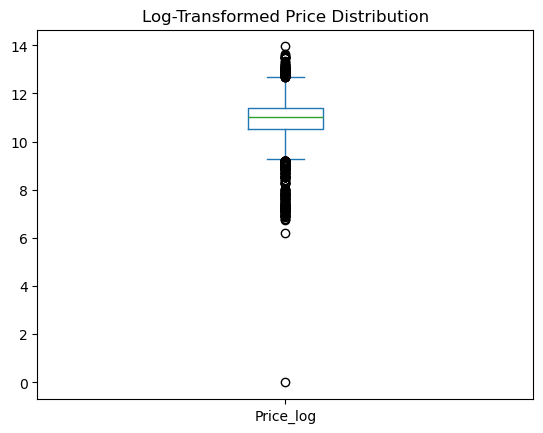

In [291]:
df['Price_log'] = np.log(df['Price'])
df['Price_log'].plot(kind='box', title='Log-Transformed Price Distribution')

In [292]:
df['Category'] = pd.cut(df['Price'],
                       bins=[0,50000,100000,150000,df['Price'].max()],
                        labels=['Budget', 'Mid', 'Premium', 'Luxury'])


In [293]:
df['Category'].value_counts()

Category
Budget     3265
Mid        3113
Premium     921
Luxury      751
Name: count, dtype: int64

In [294]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8051 entries, 0 to 8247
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Make         8051 non-null   object  
 1   Type         8051 non-null   object  
 2   Year         8051 non-null   int64   
 3   Origin       8051 non-null   object  
 4   Color        8051 non-null   object  
 5   Options      8051 non-null   object  
 6   Engine_Size  8051 non-null   float64 
 7   Fuel_Type    8051 non-null   object  
 8   Gear_Type    8051 non-null   object  
 9   Mileage      8051 non-null   int64   
 10  Region       8051 non-null   object  
 11  Price        8051 non-null   float64 
 12  Negotiable   8051 non-null   bool    
 13  Car_Age      8051 non-null   int64   
 14  Price_log    8051 non-null   float64 
 15  Category     8050 non-null   category
dtypes: bool(1), category(1), float64(3), int64(3), object(8)
memory usage: 959.4+ KB


In [295]:
df['Category'].isna().sum()
df['Category'].dropna(inplace=True) 

In [296]:
df['Year'] =pd.to_datetime(df['Year'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8051 entries, 0 to 8247
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Make         8051 non-null   object        
 1   Type         8051 non-null   object        
 2   Year         8051 non-null   datetime64[ns]
 3   Origin       8051 non-null   object        
 4   Color        8051 non-null   object        
 5   Options      8051 non-null   object        
 6   Engine_Size  8051 non-null   float64       
 7   Fuel_Type    8051 non-null   object        
 8   Gear_Type    8051 non-null   object        
 9   Mileage      8051 non-null   int64         
 10  Region       8051 non-null   object        
 11  Price        8051 non-null   float64       
 12  Negotiable   8051 non-null   bool          
 13  Car_Age      8051 non-null   int64         
 14  Price_log    8051 non-null   float64       
 15  Category     8050 non-null   category      
dtypes: bool(1),

Uni Variate Analysis

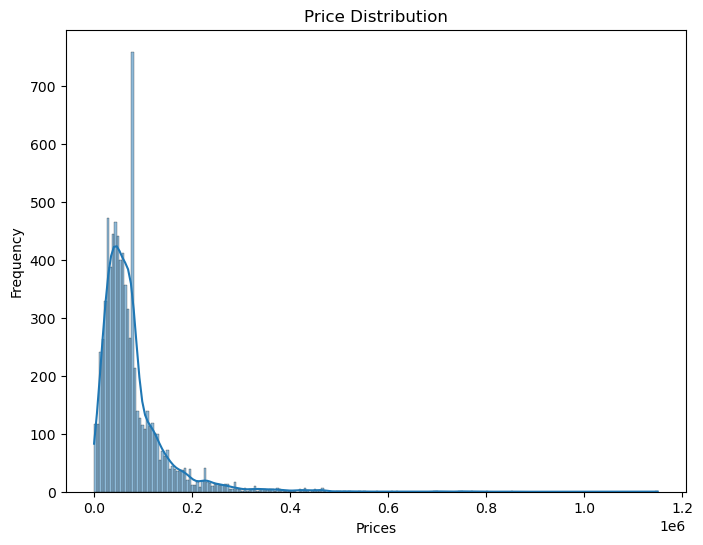

In [297]:
plt.figure(figsize=[8,6])
sns.histplot(data=df , x='Price' , kde=True )
plt.title('Price Distribution')
plt.xlabel('Prices')
plt.ylabel('Frequency')
plt.show()

It seems that the Price distribution is right-skewed, with most cars priced below 100,000 and a few expensive cars above 150,000.

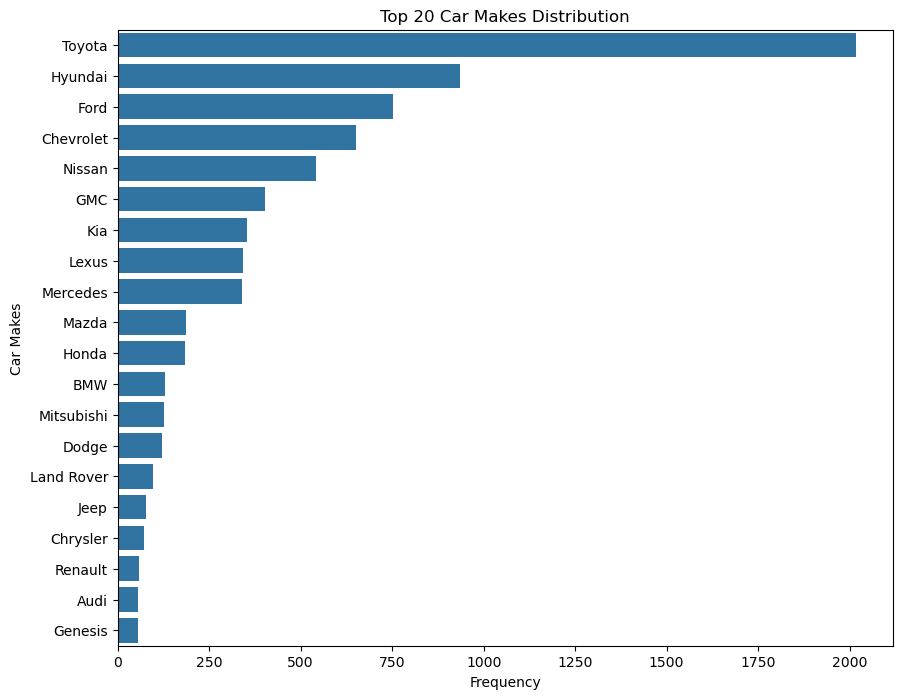

In [298]:
top_brands = df['Make'].value_counts().nlargest(20).index

plt.figure(figsize=(10, 8))  
sns.countplot(data=df[df['Make'].isin(top_brands)], y='Make', order=top_brands)
plt.title('Top 20 Car Makes Distribution')
plt.xlabel('Frequency')
plt.ylabel('Car Makes')
plt.show()

it seems that the most common car make in the dataset is Toyota, followed by Ford and Nissan

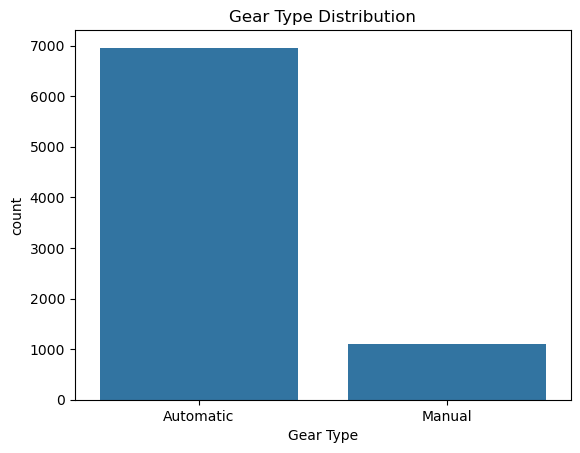

In [299]:
sns.countplot(data=df, x='Gear_Type')
plt.title('Gear Type Distribution')
plt.xlabel('Gear Type') 
plt.show()

it seems that most cars are Automatic

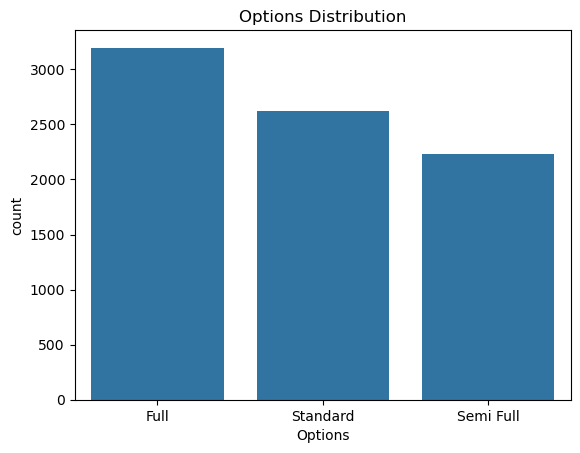

In [300]:
sns.countplot(data=df, x='Options')
plt.title('Options Distribution')
plt.xlabel('Options')
plt.show()

it seems that most of cars are with full options then standard then semi full

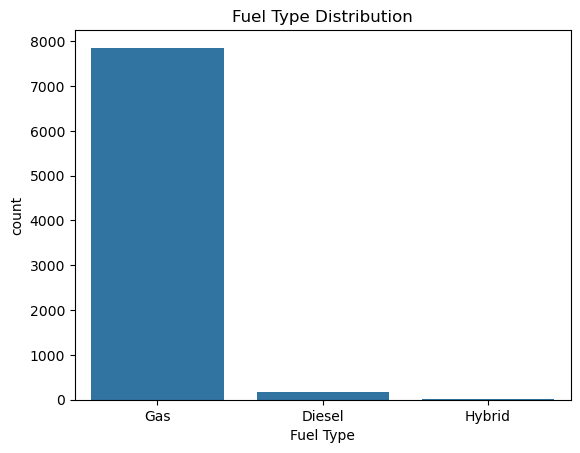

In [301]:
sns.countplot(data=df, x='Fuel_Type')
plt.title('Fuel Type Distribution')
plt.xlabel('Fuel Type')
plt.show()

it seems that most cars are Gas

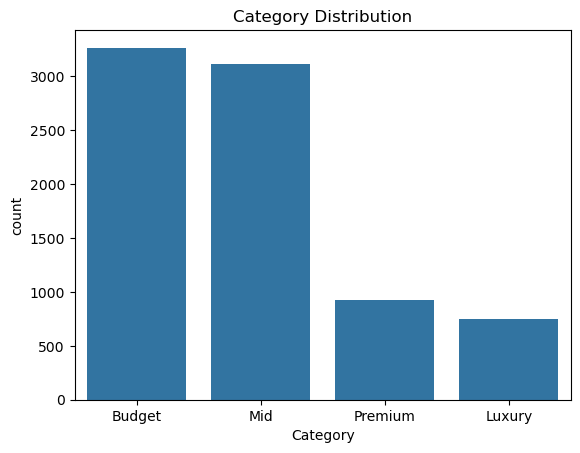

In [302]:
sns.countplot(data=df, x='Category')
plt.title('Category Distribution')
plt.xlabel('Category')
plt.show()

it seems that most cars are in Budget and Mid

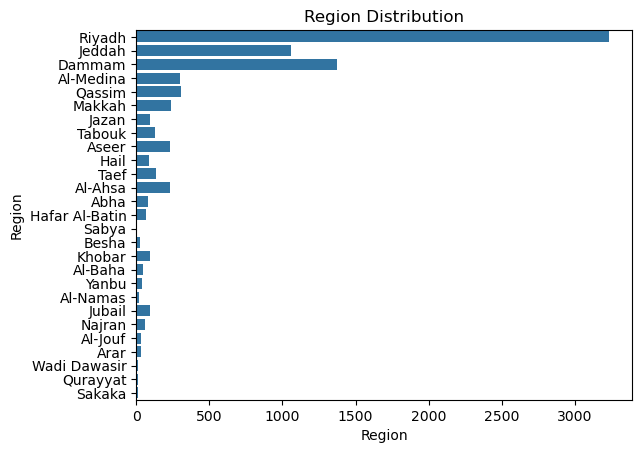

In [303]:
sns.countplot(data=df, y='Region')
plt.title('Region Distribution')
plt.xlabel('Region')
plt.show()

it seems the most capacity city is Riyadh

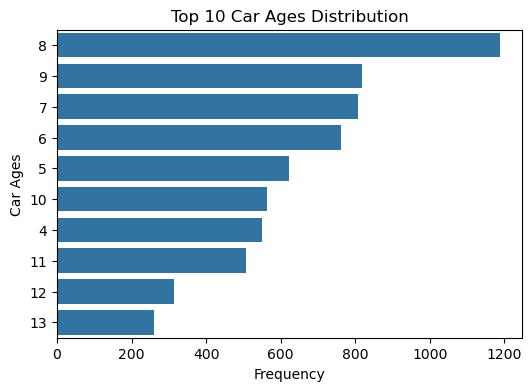

In [304]:
top_Ages = df['Car_Age'].value_counts().nlargest(10).index

plt.figure(figsize=(6, 4))  
sns.countplot(data=df[df['Car_Age'].isin(top_Ages)], y='Car_Age', order=top_Ages)
plt.title('Top 10 Car Ages Distribution')
plt.xlabel('Frequency')
plt.ylabel('Car Ages')
plt.show()

it seems that most of the cars are between 4 and 13 years old, with a peak around 8 years old

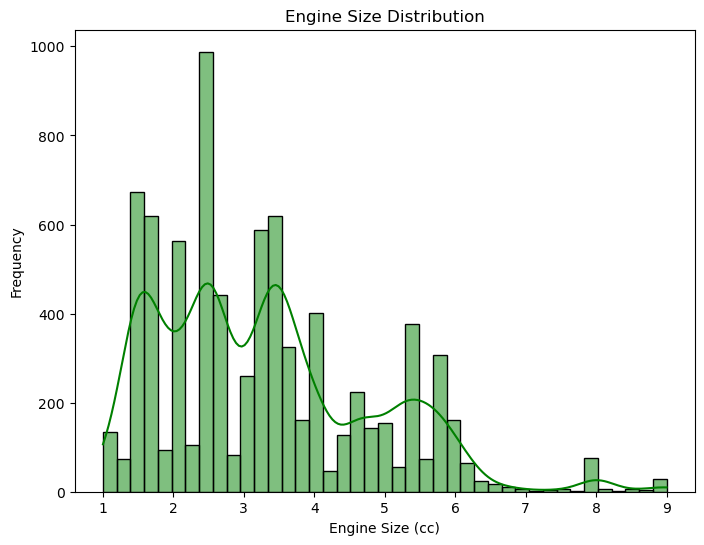

In [305]:
plt.figure(figsize=[8,6])
sns.histplot(data=df , x='Engine_Size', kde=True , color='g')
plt.title('Engine Size Distribution')
plt.xlabel('Engine Size (cc)')
plt.ylabel('Frequency')
plt.show()


it seems like that most cars have 2500 CC

Bi Variate Analysis

In [306]:
df.groupby('Category')['Price'].describe()

C:\Users\watan\AppData\Local\Temp\ipykernel_18748\3320745893.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Budget,3265.0,31099.632723,12696.485640,1.000000,22000.000000,32000.0,41923.076923,50000.0
Mid,3113.0,71488.018585,12511.347682,50131.235294,60000.000000,72000.0,77000.000000,100000.0
Premium,921.0,123158.153299,13675.098287,100750.000000,110416.666667,120000.0,133000.000000,150000.0
Luxury,751.0,240840.800807,106214.977920,151000.000000,175000.000000,206500.0,265000.000000,1150000.0


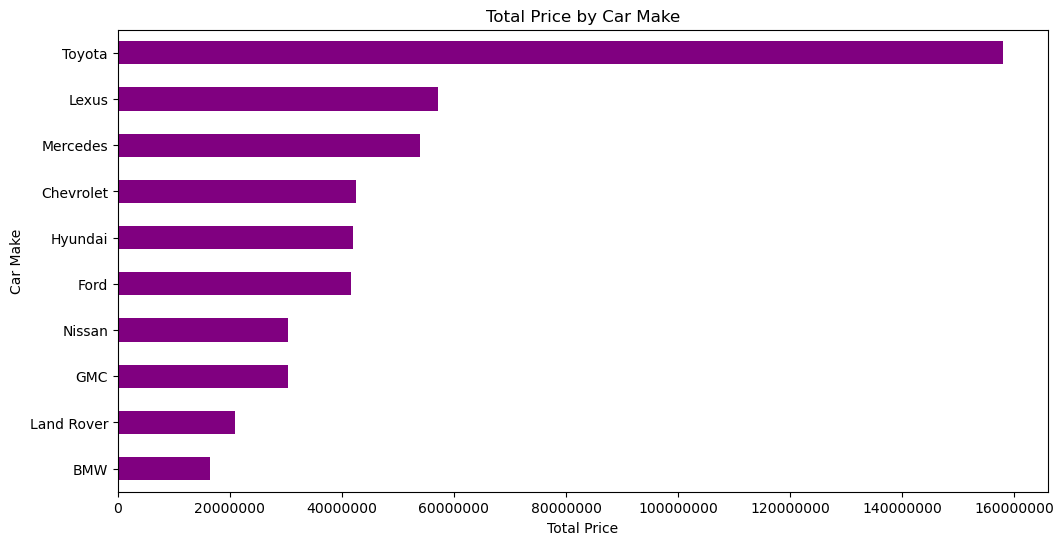

In [307]:
plt.figure(figsize=(12, 6))   
df.groupby('Make')['Price'].sum().nlargest(10).sort_values(ascending=True).plot(kind='barh', color='purple')
plt.title('Total Price by Car Make')
plt.xlabel('Total Price')
plt.ylabel('Car Make')
plt.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.show()    

it seems that Toyota is the most expensive car make in total price, which could be due to its popularity and high demand in the used car market

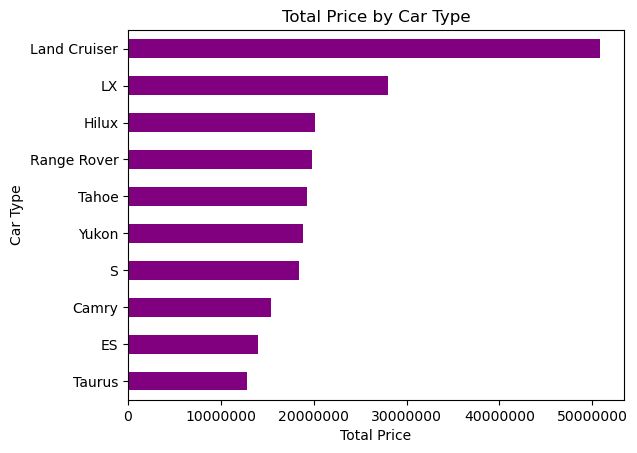

In [308]:
df.groupby('Type')['Price'].sum().nlargest(10).sort_values(ascending=True).plot(kind='barh', color='purple')
plt.title('Total Price by Car Type')
plt.xlabel('Total Price')
plt.ylabel('Car Type')
plt.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.show() 

it seems that the most expensive car type is Land Cruiser

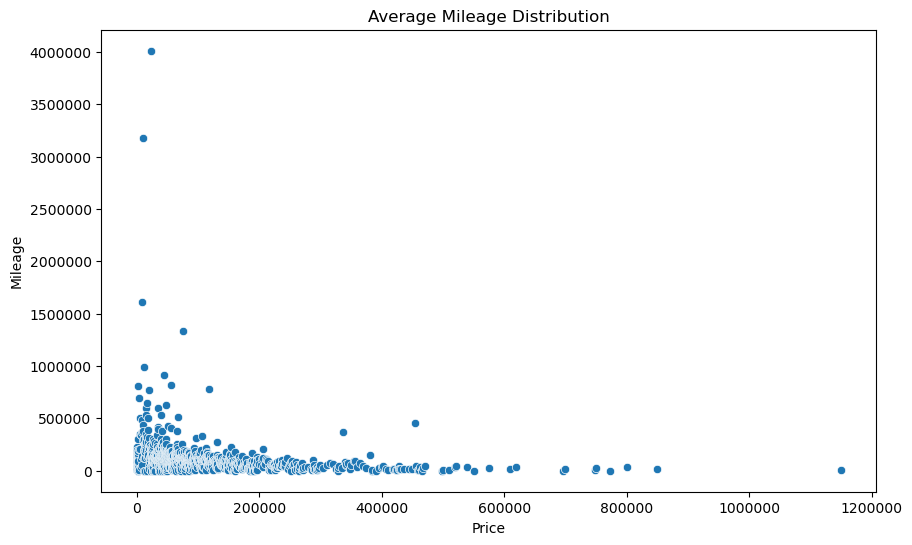

In [309]:
plt.figure(figsize=(10, 6))   
df_avg = df.groupby('Price')['Mileage'].mean().reset_index()
sns.scatterplot(data=df_avg, x='Price', y='Mileage')
plt.title('Average Mileage Distribution')
plt.ticklabel_format(style='plain', axis='both', useOffset=False)
plt.show()

it seems that there is no clear relationship between price and mileage

C:\Users\watan\AppData\Local\Temp\ipykernel_18748\2914480930.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



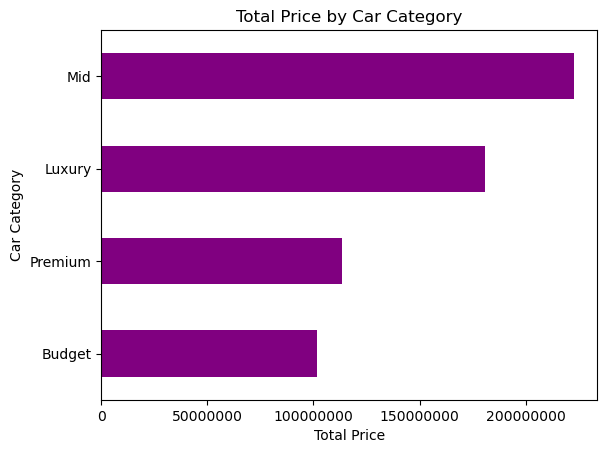

In [310]:
df.groupby('Category')['Price'].sum().nlargest(10).sort_values(ascending=True).plot(kind='barh', color='purple')
plt.title('Total Price by Car Category')
plt.xlabel('Total Price')
plt.ylabel('Car Category')
plt.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.show() 

it seems that mid category is the best

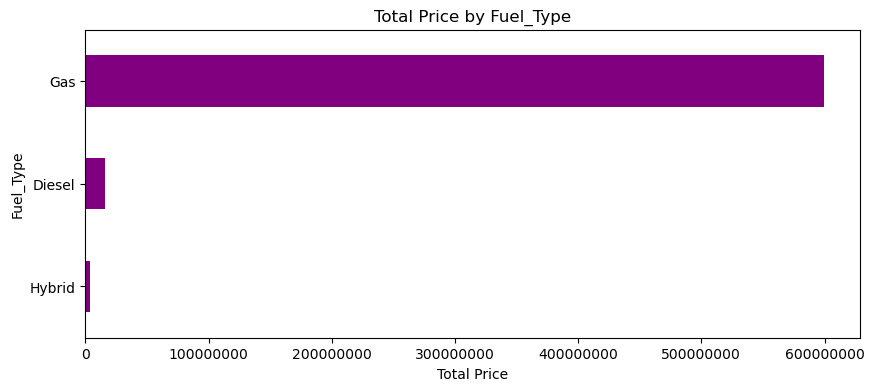

In [311]:
plt.figure(figsize=(10, 4))
df.groupby('Fuel_Type')['Price'].sum().nlargest(10).sort_values(ascending=True).plot(kind='barh', color='purple')
plt.title('Total Price by Fuel_Type')
plt.xlabel('Total Price')
plt.ylabel('Fuel_Type')
plt.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.show() 

it seems that most prices in gas cars

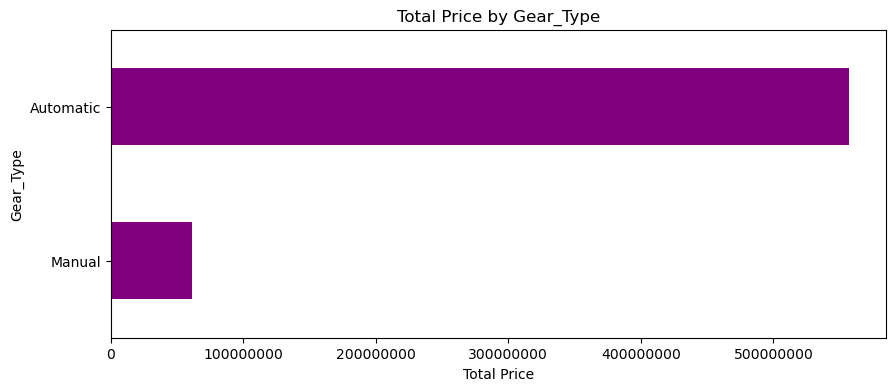

In [312]:
plt.figure(figsize=(10, 4))
df.groupby('Gear_Type')['Price'].sum().nlargest(10).sort_values(ascending=True).plot(kind='barh', color='purple')
plt.title('Total Price by Gear_Type')
plt.xlabel('Total Price')
plt.ylabel('Gear_Type')
plt.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.show() 

it seems that Automatic is more higher than manual

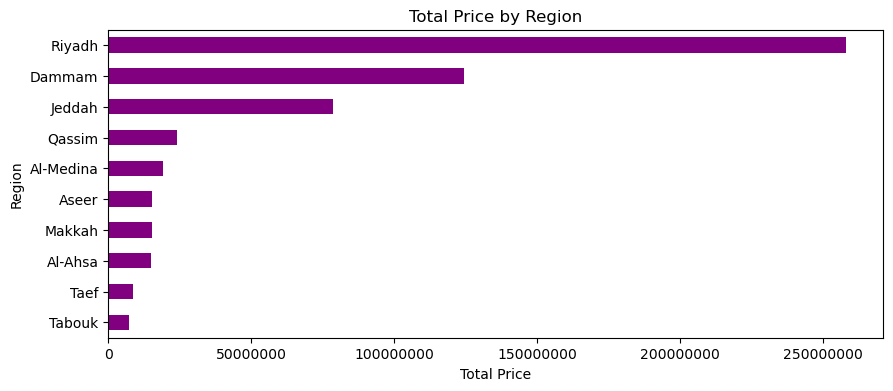

In [313]:
plt.figure(figsize=(10, 4))
df.groupby('Region')['Price'].sum().nlargest(10).sort_values(ascending=True).plot(kind='barh', color='purple')
plt.title('Total Price by Region')
plt.xlabel('Total Price')
plt.ylabel('Region')
plt.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.show() 

the most money in Riyadh

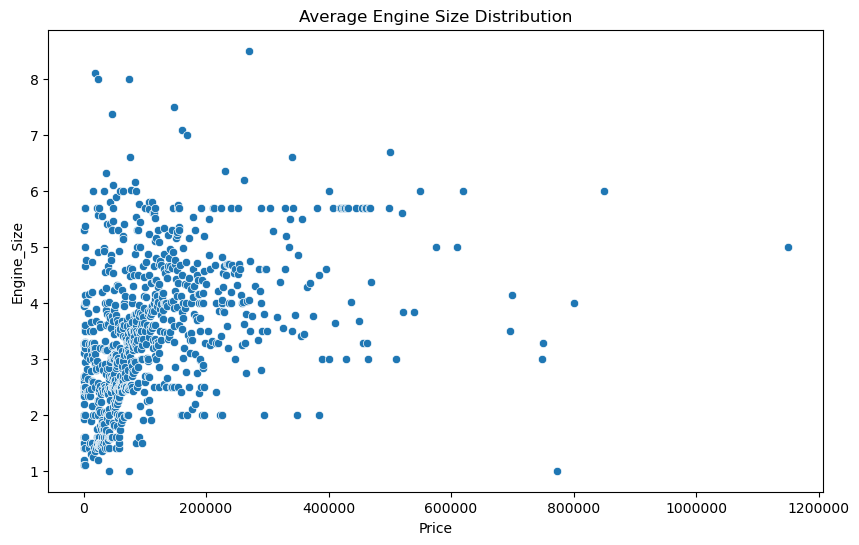

In [314]:
plt.figure(figsize=(10, 6))   
df_avg = df.groupby('Price')['Engine_Size'].mean().reset_index()
sns.scatterplot(data=df_avg, x='Price', y='Engine_Size')
plt.title('Average Engine Size Distribution')
plt.ticklabel_format(style='plain', axis='both', useOffset=False)
plt.show()

it seems that there is no relation between Engine Size and Price

In [315]:
df.to_csv('data_cleaned.csv', index=False)